# Baseline Model: Logistic Regression

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style = 'whitegrid')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## Load and Prepare Data

In [2]:
df = pd.read_csv('/Users/chldbng/Documents/projects/customer-churn-predictor/data/raw/telco-customer-churn.csv')

df['TotalCharges'] = df['TotalCharges'].apply(lambda x: 0 if str(x).strip() == '' else x)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['TotalCharges'].fillna(0, inplace = True)

df.drop(columns = ['customerID'], inplace = True)

print('✅ Remaining NaNs:', df.isnull().sum().sum())

print(f'✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

✅ Remaining NaNs: 0
✅ Data loaded: 7043 rows, 20 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Encode Categorical Variables

In [3]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    df[col] = df[col].replace({'No internet service': 'No'})
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

multi_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'MultipleLines']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

remaining_nans = df.isnull().sum().sum()
print(f'Remaining NaN values: {remaining_nans}')
print(f'✅ Encoding done. New shape: {df.shape}')
df.head()

Remaining NaN values: 0
✅ Encoding done. New shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_Yes
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,True,False,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,True,False
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,True,False
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,True,False,False,True,False,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,True,False,False


## Split Features and Target

In [4]:
X = df.drop(columns = ['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f'✅ Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Churn rate in train: {y_train.mean():.2%}')
print(f'Churn rate in test: {y_test.mean():.2%}')

nan_counts = X_train.isnull().sum()
print('Columns with NaN values:')
print(nan_counts[nan_counts > 0])
print(f'\nTotal NaN values: {X_train.isnull().sum().sum()}')

✅ Train size: 5634 | Test size: 1409
Churn rate in train: 26.54%
Churn rate in test: 26.54%
Columns with NaN values:
Series([], dtype: int64)

Total NaN values: 0


## Build and Train Logistic Regression

In [5]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42))])
pipeline.fit(X_train, y_train)


print('✅ Model trained successfully')

✅ Model trained successfully


## Evaluation on Test Set

In [12]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print('=' * 50)
print('CLASSIFICATION REPORT')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names = ['No Churn', 'Churn']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob): .4f}')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score:  0.8415


## Confusion Matrix

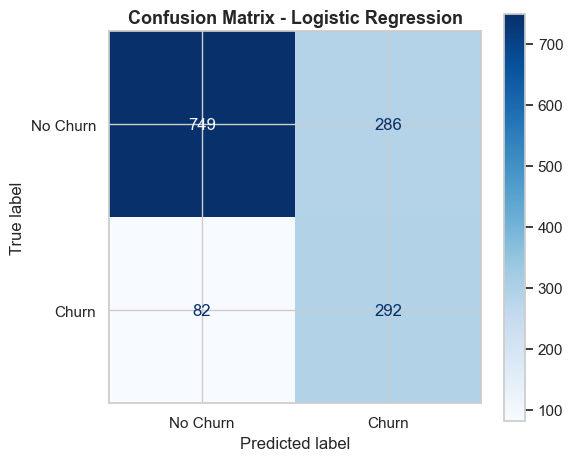

In [8]:
fig, ax = plt.subplots(figsize = (6,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels = ['No Churn', 'Churn'], cmap = 'Blues', ax = ax)

ax.set_title('Confusion Matrix - Logistic Regression', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC Curve

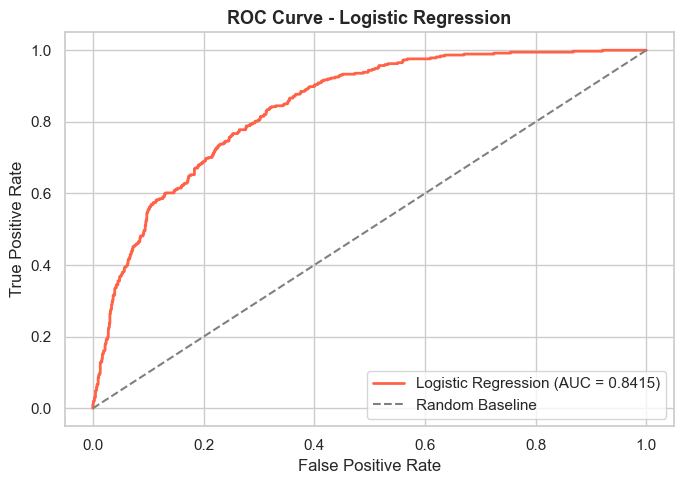

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize = (7,5))
plt.plot(fpr, tpr, color = 'tomato', lw = 2, label = f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0,1],[0,1], color = 'gray', linestyle = '--', label = 'Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression', fontsize = 13, fontweight = 'bold')
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross Validation

In [13]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

cv_auc = cross_val_score(pipeline, X, y, cv = cv, scoring = 'roc_auc')
cv_f1 = cross_val_score(pipeline, X, y, cv = cv, scoring = 'f1')

print('=' * 50)
print('5-FOLD CROSS VALIDATION RESULTS')
print('=' * 50)
print(f'ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'F1 Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

5-FOLD CROSS VALIDATION RESULTS
ROC-AUC: 0.8451 ± 0.0133
F1 Score: 0.6257 ± 0.0103


## Feature Importance

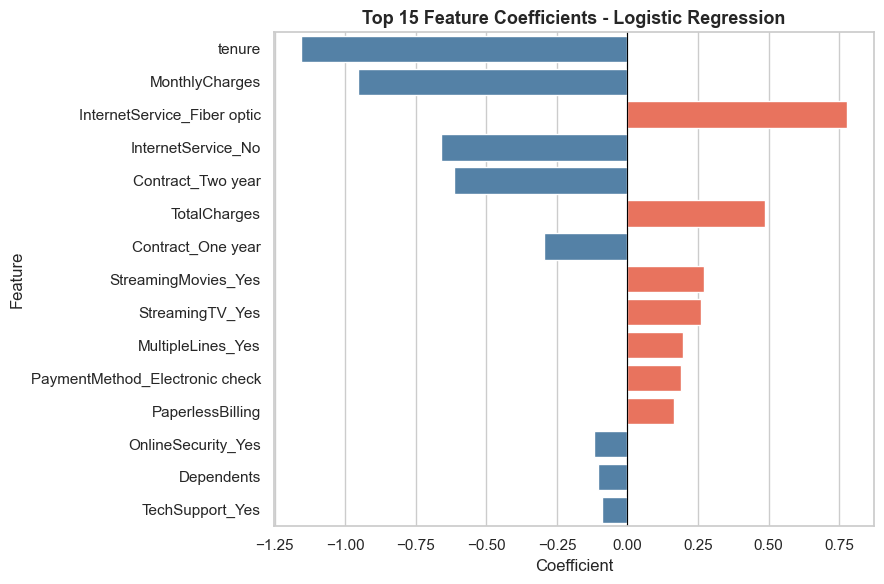

In [15]:
feature_names = X.columns.tolist()
coefficients = pipeline.named_steps['model'].coef_[0]

feat_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients}).sort_values('Coefficient', key = abs, ascending = False).head(15)

plt.figure(figsize = (9,6))
colors = ['tomato' if c > 0 else 'steelblue' for c in feat_importance['Coefficient']]
sns.barplot(feat_importance, x = 'Coefficient', y = 'Feature', palette = colors)
plt.axvline(0, color = 'black', linewidth = 0.8)
plt.title('Top 15 Feature Coefficients - Logistic Regression', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## Save the Model

In [17]:
import pickle

with open('../models/logistic_regression_baseline.pkl', 'wb') as f:pickle.dump(pipeline, f)

print('✅ Model saved to models/logistic_regression_baseline.pkl')

✅ Model saved to models/logistic_regression_baseline.pkl
